In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from os import listdir

train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir = '/content/drive/MyDrive/Hands40/val'
test_dir = '/content/drive/MyDrive/Hands40/test'

import os

base_path = '/content/drive/MyDrive/Hands40'  # adjust as needed


classes = sorted(listdir(train_dir))  # Ensure consistent class indices

image_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.05,
    horizontal_flip=True
)


train_data = train_gen.flow_from_directory(
    train_dir, classes=classes, target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=True
)

val_data = val_gen.flow_from_directory(
    val_dir, classes=classes, target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=False
)

test_data = val_gen.flow_from_directory(
    test_dir, classes=classes, target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=False
)

num_classes = len(classes)


from os import listdir
print(sorted(listdir(train_dir)))

print(train_data.class_indices)
print(train_data.labels[:10])
print(train_data.class_indices == val_data.class_indices)

Found 818 images belonging to 40 classes.
Found 159 images belonging to 40 classes.
Found 220 images belonging to 40 classes.
['class_001', 'class_002', 'class_003', 'class_004', 'class_005', 'class_006', 'class_007', 'class_008', 'class_009', 'class_010', 'class_011', 'class_012', 'class_013', 'class_014', 'class_015', 'class_016', 'class_017', 'class_018', 'class_019', 'class_020', 'class_021', 'class_022', 'class_023', 'class_024', 'class_025', 'class_026', 'class_027', 'class_028', 'class_029', 'class_030', 'class_031', 'class_032', 'class_033', 'class_034', 'class_035', 'class_036', 'class_037', 'class_038', 'class_039', 'class_040']
{'class_001': 0, 'class_002': 1, 'class_003': 2, 'class_004': 3, 'class_005': 4, 'class_006': 5, 'class_007': 6, 'class_008': 7, 'class_009': 8, 'class_010': 9, 'class_011': 10, 'class_012': 11, 'class_013': 12, 'class_014': 13, 'class_015': 14, 'class_016': 15, 'class_017': 16, 'class_018': 17, 'class_019': 18, 'class_020': 19, 'class_021': 20, 'clas

In [ ]:
pip install torch torchvision timm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 872.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.1 MB/s eta 0:00:00


In [ ]:
# 🧠 Imports
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir = '/content/drive/MyDrive/Hands40/val'
test_dir = '/content/drive/MyDrive/Hands40/test'




# 📌 Parameters
num_classes = 40
batch_size = 32
image_size = 256
epochs = 70
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 🎨 Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])



val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 📦 Datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)




# 📉 Label Smoothing Loss
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x, target):
        logprobs = self.log_softmax(x)
        with torch.no_grad():
            true_dist = torch.zeros_like(logprobs)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * logprobs, dim=-1))

# 🧠 Model
model = timm.create_model('resnet18', pretrained=True, num_classes=40)
model.to(device)

criterion = LabelSmoothingLoss(classes=num_classes, smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

# 🔁 Train & Eval Functions
def train(model, loader):

    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
            total += y.size(0)
    return total_loss / total, correct / total, preds, labels


In [ ]:
# 🚀 Training Loop
train_accs, val_accs = [], []
train_losses, val_losses = [], []

best_val_acc = 0
patience = 10
no_improve_epochs = 0

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

    # 🔁 Early stopping logic
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve_epochs = 0
        # ✅ Optional: Save best model weights
        torch.save(model.state_dict(), "best_resnet18_model.pth")
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs} epoch(s)")

    if no_improve_epochs >= patience:
        print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
        break


Epoch 1/70 - Train Acc: 0.0281, Val Acc: 0.0503, Val Loss: 3.6791
Epoch 2/70 - Train Acc: 0.0538, Val Acc: 0.0818, Val Loss: 3.6535
Epoch 3/70 - Train Acc: 0.0709, Val Acc: 0.1069, Val Loss: 3.6322
Epoch 4/70 - Train Acc: 0.0733, Val Acc: 0.1069, Val Loss: 3.6085
No improvement for 1 epoch(s)
Epoch 5/70 - Train Acc: 0.0758, Val Acc: 0.1006, Val Loss: 3.5899
No improvement for 2 epoch(s)
Epoch 6/70 - Train Acc: 0.0831, Val Acc: 0.1006, Val Loss: 3.5791
No improvement for 3 epoch(s)
Epoch 7/70 - Train Acc: 0.0770, Val Acc: 0.1069, Val Loss: 3.5691
No improvement for 4 epoch(s)
Epoch 8/70 - Train Acc: 0.0770, Val Acc: 0.1006, Val Loss: 3.5605
No improvement for 5 epoch(s)
Epoch 9/70 - Train Acc: 0.0819, Val Acc: 0.1006, Val Loss: 3.5577
No improvement for 6 epoch(s)
Epoch 10/70 - Train Acc: 0.0831, Val Acc: 0.1006, Val Loss: 3.5573
No improvement for 7 epoch(s)
Epoch 11/70 - Train Acc: 0.0782, Val Acc: 0.1069, Val Loss: 3.5271
No improvement for 8 epoch(s)
Epoch 12/70 - Train Acc: 0.0868,

In [ ]:
# 🎯 Final Test Evaluation
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


✅ Test Accuracy: 0.7273, Test Loss: 1.7721


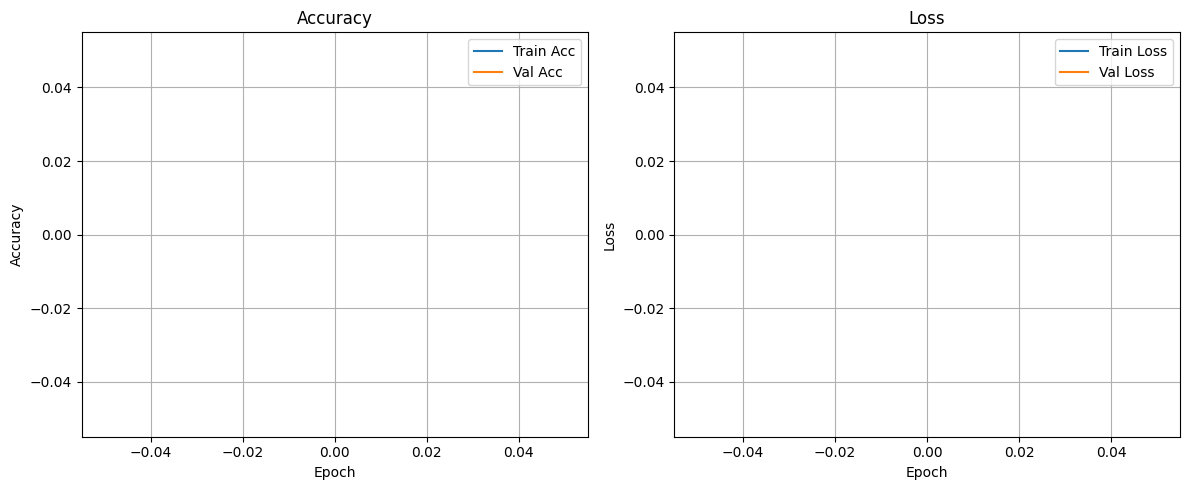

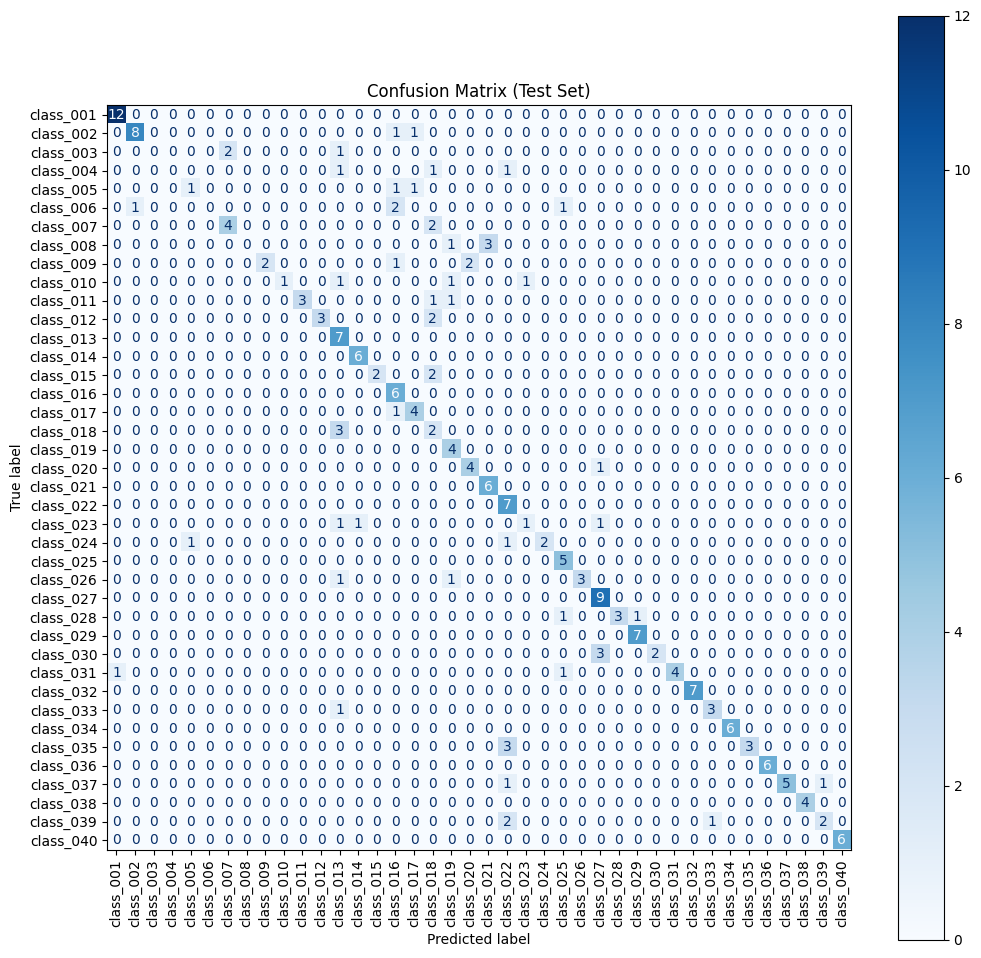

In [ ]:
# 📊 Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# 📉 Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()